## Session 3: Using gene descriptions and GPT to generate gene embeddings
(*updated to 2026 for OpenRouter API*)

---

기존 Foundation Model은 유전자 표현 Profile에서 유전자 및 세포 기능을 간접 학습합니다. 이 때문에, 광범위한 데이터 큐레이션 및 많은 리소스 투입을 요구합니다.

반면, 개별 유전자의 NCBI text description 및 GPT를 활용하여 gene embedding을 생성하고, 이 gene embedding으로 각종 task를 수행합니다.

In [1]:
from openai import OpenAI

import pandas as pd
import json 
import numpy as np
import pickle

import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
PATH = "./DATA/"
OPENROUTER_API_KEY = ""

# Data download from github and save to PATH
BASE_URL = "https://raw.githubusercontent.com/leelabsg/clinical-llm-tutorial/main/Session3"

!wget -qP $PATH {BASE_URL}/gene_embeddings_text-embedding-3-small_trimmed.pkl
!wget -qP $PATH {BASE_URL}/NCBI_cleaned_summary_of_genes.json
!wget -qP $PATH {BASE_URL}/gene2vec/test_label.txt
!wget -qP $PATH {BASE_URL}/gene2vec/test_text.txt
!wget -qP $PATH {BASE_URL}/gene2vec/train_label.txt
!wget -qP $PATH {BASE_URL}/gene2vec/train_text.txt

print("Download complete.")

Download complete.


## 1. Set Up OpenRouter API to use embeddings

In [3]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

# ── Privacy provider config (reused across all requests) ──────
PROVIDER_CONFIG = {
    "zdr": True,
    "data_collection": "deny",
}

Embedding 모델은 OpenAI의 "text-embedding-3-small" 사용, 용도에 따라서 다른 Embedding Model로도 대체 가능

In [4]:
EMBED_MODEL = "openai/text-embedding-3-small"
BATCH_SIZE = 256

In [5]:
## 전 단계에서 생성한 NCBI gene summary 파일 적재
with open(f"{PATH}NCBI_cleaned_summary_of_genes.json", "r", encoding="utf-8") as f:
    summaries = json.load(f)



In [6]:
print(summaries['CCND1'])

The protein encoded by this gene belongs to the highly conserved cyclin family, whose members are characterized by a dramatic periodicity in protein abundance throughout the cell cycle. Cyclins function as regulators of CDK kinases. Different cyclins exhibit distinct expression and degradation patterns which contribute to the temporal coordination of each mitotic event. This cyclin forms a complex with and functions as a regulatory subunit of CDK4 or CDK6, whose activity is required for cell cycle G1/S transition. This protein has been shown to interact with tumor suppressor protein Rb and the expression of this gene is regulated positively by Rb. Mutations, amplification and overexpression of this gene, which alters cell cycle progression, are observed frequently in a variety of human cancers. [provided by RefSeq, Dec 2019].


In [7]:
text_input = summaries['ANO1']
resp = client.embeddings.create(model=EMBED_MODEL, input=text_input)
print(resp.data[0].embedding)
print(len(resp.data[0].embedding))

[-0.0147247314453125, 0.005870819091796875, 0.01995849609375, 0.06365966796875, 0.0098419189453125, 0.0006175041198730469, 0.05059814453125, -0.002864837646484375, -0.05859375, -0.04010009765625, 0.020233154296875, 0.040008544921875, 0.0178070068359375, 0.046051025390625, 0.0386962890625, -0.03033447265625, -0.0237274169921875, 0.01434326171875, -0.02557373046875, 0.055908203125, 0.006683349609375, -0.03564453125, -0.0211639404296875, 0.023406982421875, -0.052825927734375, -0.061004638671875, -0.044189453125, -0.00484466552734375, -0.022552490234375, -0.020904541015625, 0.034149169921875, -0.01056671142578125, -0.01479339599609375, 0.007556915283203125, -0.00714874267578125, 0.019012451171875, 0.033782958984375, 0.035125732421875, -0.0278167724609375, 0.01343536376953125, 0.0049896240234375, -0.016357421875, -0.017547607421875, -0.01140594482421875, -0.046905517578125, -0.030517578125, -0.0677490234375, -0.005847930908203125, -0.0169830322265625, -0.005840301513671875, -0.0061416625976

### 2. Utilize generated gene embeddings in tasks

In [8]:
import pickle

with open(f"{PATH}gene_embeddings_text-embedding-3-small_trimmed.pkl", "rb") as fp:
    GPT_gene_embeddings = pickle.load(fp)

In [10]:
print(GPT_gene_embeddings['CCND1'])
len(GPT_gene_embeddings)

[0.00842596 0.03714848 0.05775443 ... 0.03479705 0.00315845 0.00276396]


10898

#### [Task] Gene-gene interaction prediction

본 예제에서는 생성된 gene embedding의 gene-gene interaction 예측 성능을 Gene2vec 및 무작위 embeddings에 비교해서 보여줍니다.

The input data downloaded from https://github.com/jingcheng-du/Gene2vec repo.

In [11]:
# gene gene interaction 
train_text_GGI = pd.read_csv(f'{PATH}gene2vec/train_text.txt',sep=' ', header=None)
train_label_GGI = pd.read_csv(f'{PATH}gene2vec/train_label.txt', header=None)
train_text_GGI.columns = ['gene_1','gene_2']
train_label_GGI.columns = ['label']
train_text_GGI_df = pd.concat([train_text_GGI,train_label_GGI], axis=1)

test_text_GGI = pd.read_csv(f'{PATH}gene2vec/test_text.txt',sep=' ', header=None)
test_label_GGI = pd.read_csv(f'{PATH}gene2vec/test_label.txt', header=None)
test_text_GGI.columns = ['gene_1','gene_2']
test_label_GGI.columns = ['label']
test_text_GGI_df = pd.concat([test_text_GGI,test_label_GGI], axis=1)

In [12]:
print(train_text_GGI_df.head())


   gene_1  gene_2  label
0   GPNMB    BAP1      1
1   GPR34  CARD16      0
2    ELF5   TGFB2      1
3  LILRB2    NCR2      1
4   CRMP1    DLX5      1


Featurization applied by adding embedding vectors of the two genes together

1. Gene-gene interaction with gene embeddings

In [13]:
X_array_train = []
y_array_train = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  GPT_gene_embeddings \
        and row['gene_2'] in GPT_gene_embeddings:
        X_array_train.append(GPT_gene_embeddings[row['gene_1']]+\
                             GPT_gene_embeddings[row['gene_2']])
        y_array_train.append(row['label'])
X_array_train = np.array(X_array_train)
y_array_train = np.array(y_array_train)
X_array_train = X_array_train.reshape(X_array_train.shape[0],-1)

X_array_test = []
y_array_test = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  GPT_gene_embeddings \
        and row['gene_2'] in GPT_gene_embeddings:
        X_array_test.append(GPT_gene_embeddings[row['gene_1']]+\
                             GPT_gene_embeddings[row['gene_2']])
        y_array_test.append(row['label'])
X_array_test = np.array(X_array_test)
y_array_test = np.array(y_array_test)
X_array_test = X_array_test.reshape(X_array_test.shape[0],-1)

In [14]:
print(X_array_train.shape, y_array_train.shape, X_array_test.shape, y_array_test.shape)
print(y_array_train[:5,])

(250692, 1536) (250692,) (20346, 1536) (20346,)
[1 0 1 1 1]


In [15]:
# Using logistic regression for the gene embeddings
lr = LogisticRegression()  # Add hyperparameters like n_estimators if needed
lr.fit(X_array_train, y_array_train)
y_pred_lr = lr.predict_proba(X_array_test)

# Computing the ROC curve with _lr suffix
fpr_lr, tpr_lr, _ = sklearn.metrics.roc_curve(y_array_test, y_pred_lr[:, 1])


<Figure size 640x480 with 0 Axes>

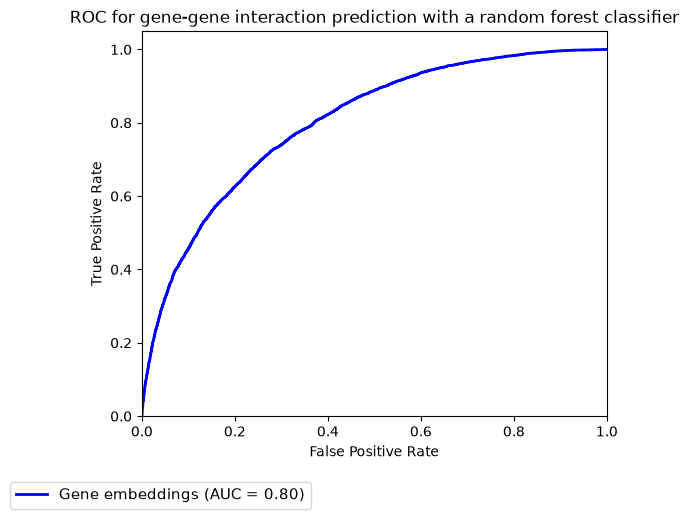

In [16]:
# Plot ROC curves
plt.figure()
# Existing Logistic Regression curves
# ... your existing plot code for Logistic Regression here ...
plt.figure(figsize=(6,5))
# Add Random Forest ROC curves
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, 
         label='Gene embeddings (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test, y_pred_lr[:,1])))

# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC for gene-gene interaction prediction with a random forest classifier')
plt.legend(loc='upper left',bbox_to_anchor=(-0.3, -0.15),fontsize=11,ncol=3)